In [3]:
!pip install groq pandas google-api-python-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 9.0 MB/s eta 0:00:00


In [4]:
import time
from googleapiclient.discovery import build
from groq import Groq
import pandas as pd

# 1. CONFIGURATION
YOUTUBE_API_KEY = "your_youtube_api_key"
GROQ_API_KEY = "your_groq_api_key"
VIDEO_ID = "k5JGWmG_SDo"

# 2. APIS SETUP
youtube = build("youtube", "v3", developerKey=YOUTUBE_API_KEY)
groq_client = Groq(api_key=GROQ_API_KEY)


# 3. MAIN COMMENTS ONLY FUNCTION (WITHOUT REPLIES)
def get_clean_main_comments(video_id):
    comments = []
    next_page_token = None
    while True:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            textFormat="plainText",
            pageToken=next_page_token,
        )
        response = request.execute()
        for item in response["items"]:
            comment = item["snippet"]["topLevelComment"]["snippet"]["textDisplay"]
            comments.append(comment)
        next_page_token = response.get("nextPageToken")
        if not next_page_token:
            break
    return comments


# 4. STREAMLINED GROQ SENTIMENT FUNCTION
def analyze_sentiment_groq(comment_text):
    single_prompt = (
        "You are an expert AI data analyst for a luxury watch brand.\n"
        "Analyze the sentiment of the user comment provided below.\n"
        "Respond with EXACTLY ONE WORD from these three choices: 'Positive', 'Negative', or 'Neutral'.\n"
        "Do not include any other words, introduction, punctuation, or explanation.\n\n"
        f"Comment: {comment_text}"
    )

    try:
        chat_completion = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "user", "content": str(single_prompt)},
            ],
            temperature=0.0,
        )
        return chat_completion.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {str(e)[:30]}"


# 5. RUNNING THE COMPLETE PIPELINE
print("01. Fetching clean main comments from YouTube (Skipping Replies)...")
main_comments = get_clean_main_comments(VIDEO_ID)
print(f"Total valid main comments found: {len(main_comments)}")

print(f"02. Initializing Groq Sentiment Engine for all {len(main_comments)} comments...")
results = []

for index, comment in enumerate(main_comments):
    print(f"Processing comment {index+1}/{len(main_comments)}...")
    sentiment = analyze_sentiment_groq(comment)
    results.append({"User Comment": comment, "AI Sentiment": sentiment})
    time.sleep(1)

# 6. FINAL DATA PRESENTATION
df = pd.DataFrame(results)
print("\nCHRONOPULSE AI")
print(df)

01. Fetching clean main comments from YouTube (Skipping Replies)...
Total valid main comments found: 47
02. Initializing Groq Sentiment Engine for all 47 comments...
Processing comment 1/47...
Processing comment 2/47...
Processing comment 3/47...
Processing comment 4/47...
Processing comment 5/47...
Processing comment 6/47...
Processing comment 7/47...
Processing comment 8/47...
Processing comment 9/47...
Processing comment 10/47...
Processing comment 11/47...
Processing comment 12/47...
Processing comment 13/47...
Processing comment 14/47...
Processing comment 15/47...
Processing comment 16/47...
Processing comment 17/47...
Processing comment 18/47...
Processing comment 19/47...
Processing comment 20/47...
Processing comment 21/47...
Processing comment 22/47...
Processing comment 23/47...
Processing comment 24/47...
Processing comment 25/47...
Processing comment 26/47...
Processing comment 27/47...
Processing comment 28/47...
Processing comment 29/47...
Processing comment 30/47...
Pro

In [17]:
from google.colab import files

print("Exporting data to Excel CSV format...")

csv_filename = "chronopulse_ai_report.csv"
df.to_csv(csv_filename, index=False)
print(f"File '{csv_filename}' has been created successfully in memory!")

print("Starting download in your browser...")
files.download(csv_filename)

Exporting data to Excel CSV format...
File 'chronopulse_ai_report.csv' has been created successfully in memory!
Starting download in your browser...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import time
from googleapiclient.discovery import build
from groq import Groq
import pandas as pd

# 1. CONFIGURATION
YOUTUBE_API_KEY = "your_youtube_api_key"
GROQ_API_KEY = "your_groq_api_key"
VIDEO_ID = "W1LDr0Fc0ZA"

# 2. APIS SETUP
youtube = build("youtube", "v3", developerKey=YOUTUBE_API_KEY)
groq_client = Groq(api_key=GROQ_API_KEY)

# 3. PRODUCTION EXTRACTOR WITH PAGINATION
def get_clean_main_comments(video_id):
    comments = []
    next_page_token = None
    while True:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            textFormat="plainText",
            pageToken=next_page_token
        )
        response = request.execute()
        for item in response["items"]:
            comments.append(item["snippet"]["topLevelComment"]["snippet"]["textDisplay"])
        next_page_token = response.get("nextPageToken")
        if not next_page_token:
            break
    return comments

# 4. ADVANCED ASPECT-BASED NLP FUNCTION
def extract_watch_insights(comment_text):
    expert_prompt = (
        "You are an expert market research AI for a luxury watch brand.\n"
        "Analyze the user comment provided below and map it to our core business metrics.\n"
        "Fill out the following fields. For fields 1 to 4, if the comment does not mention that topic, write 'Not Mentioned'.\n\n"
        "1. Country Focus: (Write 'Swiss', 'France', 'China', or 'Not Mentioned')\n"
        "2. Craftsmanship: (Write 'Mentioned' if they discuss movements, finishing, arts, hand-lacquer, else 'Not Mentioned')\n"
        "3. Price Perception: (Write 'Overpriced', 'Good Value', 'Fair', or 'Not Mentioned')\n"
        "4. Sustainability: (Write 'Mentioned' or 'Not Mentioned')\n"
        "5. General Sentiment: (Write EXACTLY ONE: 'Positive', 'Negative', or 'Neutral')\n\n"
        "Output format must be exactly like this, separated by pipes (|), with no extra text or labels:\n"
        "Country Focus | Craftsmanship | Price Perception | Sustainability | General Sentiment\n\n"
        f"Comment: \"{comment_text}\""
    )

    try:
        chat_completion = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": str(expert_prompt)}],
            temperature=0.0,
        )
        raw_output = chat_completion.choices[0].message.content.strip()
        parts = [item.strip() for item in raw_output.split('|')]

        if len(parts) == 5:
            return parts
        else:
            return ["Not Mentioned", "Not Mentioned", "Not Mentioned", "Not Mentioned", "Neutral"]
    except Exception as e:
        return ["Error", "Error", "Error", "Error", "Error"]

# 5. RUNNING THE FULL PRODUCTION PIPELINE
print("01. Fetching absolute ALL main comments from YouTube...")
main_comments = get_clean_main_comments(VIDEO_ID)
total_count = len(main_comments)
print(f"Success! Total {total_count} main comments extracted from raw feed.")

print(f"02. Initializing Deep Aspect Analytics on all {total_count} records...")
structured_results = []

for index, comment in enumerate(main_comments):
    print(f"Analyzing Record {index+1}/{total_count}...", end="\r")
    insights = extract_watch_insights(comment)

    structured_results.append({
        "User Comment": comment,
        "Country Focus": insights[0],
        "Craftsmanship": insights[1],
        "Price Perception": insights[2],
        "Sustainability": insights[3],
        "AI Sentiment": insights[4]
    })
    time.sleep(0.5)

df = pd.DataFrame(structured_results)
print(f"\n\nAnalysis Complete! All {total_count} rows transformed into Structured Insights Matrix.")

01. Fetching absolute ALL main comments from YouTube...
Success! Total 145 main comments extracted from raw feed.
02. Initializing Deep Aspect Analytics on all 145 records...


Analysis Complete! All 145 rows transformed into Structured Insights Matrix.


In [11]:
from google.colab import files

print("Formatting and structuring enterprise export assets...")
csv_filename = "chronopulse_complete_market_report.csv"

df.to_csv(csv_filename, index=False)
print(f"Encapsulated Matrix into unified sheet structure.")

print("Initializing secure browser file payload transfer...")
files.download(csv_filename)

Formatting and structuring enterprise export assets...
Encapsulated Matrix into unified sheet structure.
Initializing secure browser file payload transfer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

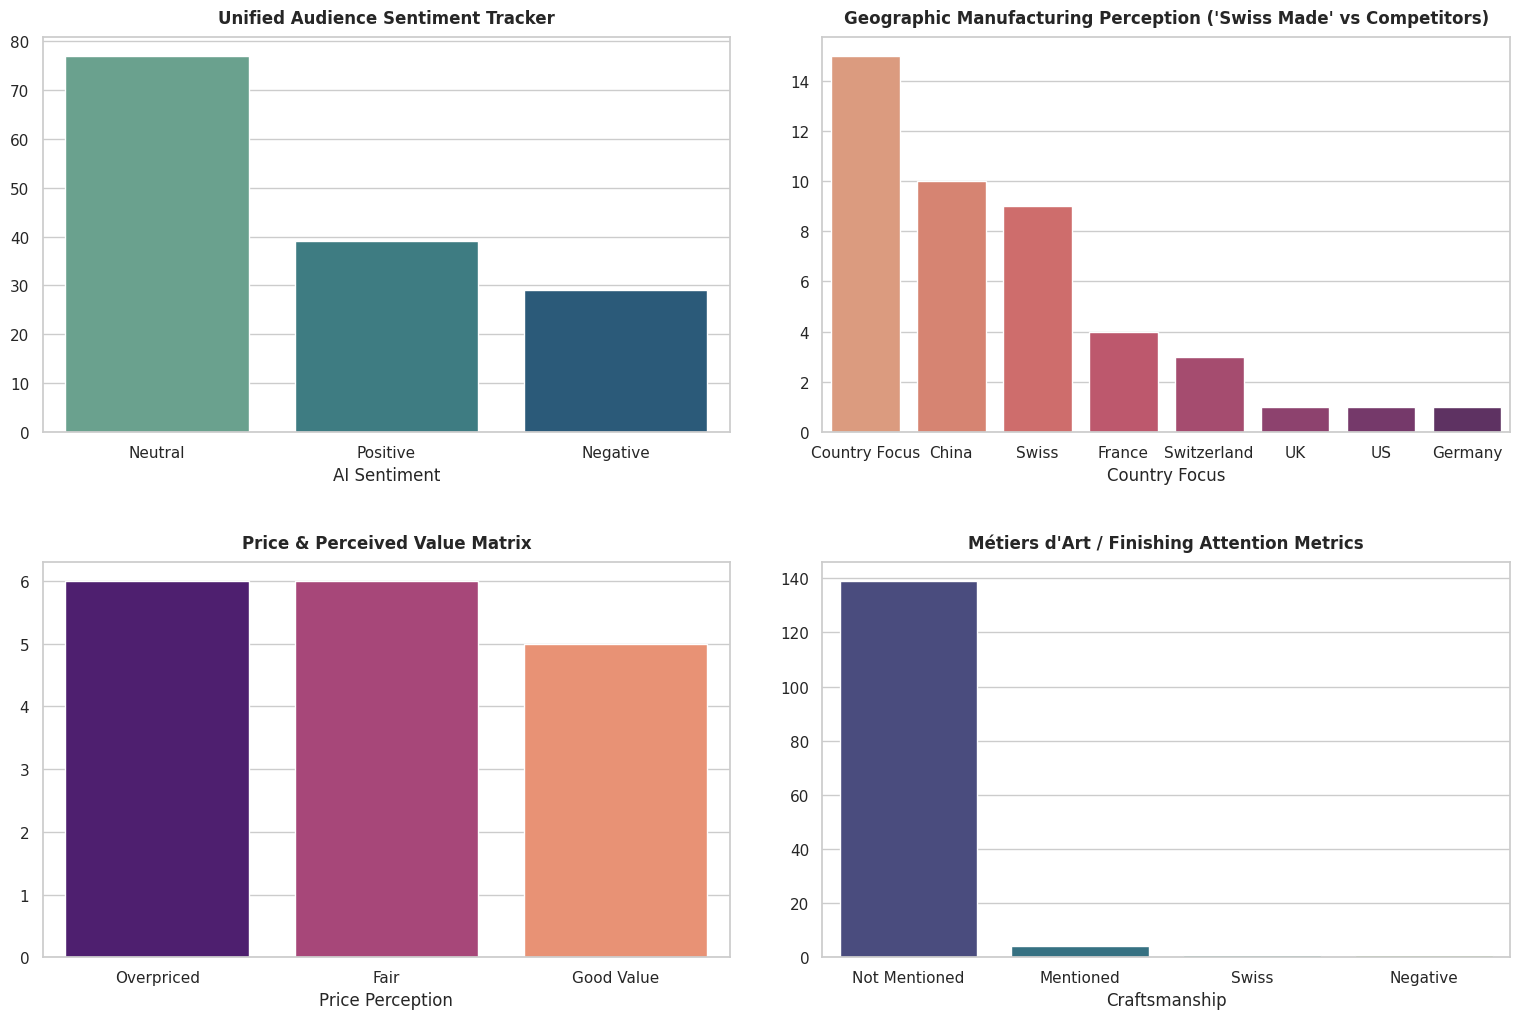


CHRONOPULSE QUANTIFIED MARKET INSIGHTS MATRIX:
• Total Audience Feedback Signals Scanned: 145
• Country Regional Mentions: Swiss (9), France (4), China (10)
• Price Disruption Alerts (Overpriced Arguments): 6 comments
• Artisanal Craftsmanship Discussion Rate: 4 touchpoints


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.set_theme(style="whitegrid")

# 1. Sentiment Engine Plot
sent_counts = df['AI Sentiment'].value_counts()
sns.barplot(x=sent_counts.index, y=sent_counts.values, ax=axes[0,0], palette="crest", hue=sent_counts.index, legend=False)
axes[0,0].set_title('Unified Audience Sentiment Tracker', fontweight='bold', pad=10)

# 2. Country Strategy Plot
country_counts = df[df['Country Focus'] != 'Not Mentioned']['Country Focus'].value_counts()
sns.barplot(x=country_counts.index, y=country_counts.values, ax=axes[0,1], palette="flare", hue=country_counts.index, legend=False)
axes[0,1].set_title("Geographic Manufacturing Perception ('Swiss Made' vs Competitors)", fontweight='bold', pad=10)

# 3. Price Value Proposition Plot
price_counts = df[df['Price Perception'] != 'Not Mentioned']['Price Perception'].value_counts()
sns.barplot(x=price_counts.index, y=price_counts.values, ax=axes[1,0], palette="magma", hue=price_counts.index, legend=False)
axes[1,0].set_title('Price & Perceived Value Matrix', fontweight='bold', pad=10)

# 4. Craftsmanship Pillar Counter
craft_counts = df['Craftsmanship'].value_counts()
sns.barplot(x=craft_counts.index, y=craft_counts.values, ax=axes[1,1], palette="viridis", hue=craft_counts.index, legend=False)
axes[1,1].set_title("Métiers d'Art / Finishing Attention Metrics", fontweight='bold', pad=10)

plt.tight_layout(pad=3.0)
plt.show()

# Corporate Executive Summary for RFP Proposals
print("\nCHRONOPULSE QUANTIFIED MARKET INSIGHTS MATRIX:")
print(f"• Total Audience Feedback Signals Scanned: {len(df)}")
print(f"• Country Regional Mentions: Swiss ({len(df[df['Country Focus']=='Swiss'])}), France ({len(df[df['Country Focus']=='France'])}), China ({len(df[df['Country Focus']=='China'])})")
print(f"• Price Disruption Alerts (Overpriced Arguments): {len(df[df['Price Perception']=='Overpriced'])} comments")
print(f"• Artisanal Craftsmanship Discussion Rate: {len(df[df['Craftsmanship']=='Mentioned'])} touchpoints")